In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [3]:
data_dir = '/home/jovyan/work/kaggle_kakr_housing/data'
train_path = join(data_dir, 'train.csv')
test_path = join(data_dir, 'test.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [4]:
test_id = test['id']

# 타겟 값(price) 분리 및 로그 변환
y = np.log1p(train['price'])
del train['price']

In [7]:
for df in [train, test]:
    if 'id' in df.columns:
        del df['id']
    if 'date' in df.columns:
        del df['date']
print(f"학습 데이터: {len(train.columns)}")

학습 데이터: 18


## 노예출동!!

In [8]:
# LightGBM 설정
lgbm_model = LGBMRegressor(
    n_estimators=1000, 
    max_depth=7,          
    learning_rate=0.05, 
    num_leaves=31, 
    random_state=42
)

# XGBoost 설정
xgb_model = XGBRegressor(
    n_estimators=1000, 
    max_depth=7,           
    learning_rate=0.05, 
    random_state=42
)

In [9]:
lgbm_model.fit(train, y)
xgb_model.fit(train, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001854 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 18
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


로그값 다시 치환

In [11]:
lgbm_pred = np.expm1(lgbm_model.predict(test))
xgb_pred = np.expm1(xgb_model.predict(test))

In [14]:
final_pred = (lgbm_pred * 0.5) + (xgb_pred * 0.5)

Slave 어쎔블!!!!!!!!

In [17]:
submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)
submission['price'] = final_pred

final_csv_name = join(data_dir, 'AvengersLave.csv')
submission.to_csv(final_csv_name, index=False)

print(f"제출 파일: {final_csv_name}")

제출 파일: /home/jovyan/work/kaggle_kakr_housing/data/AvengersLave.csv


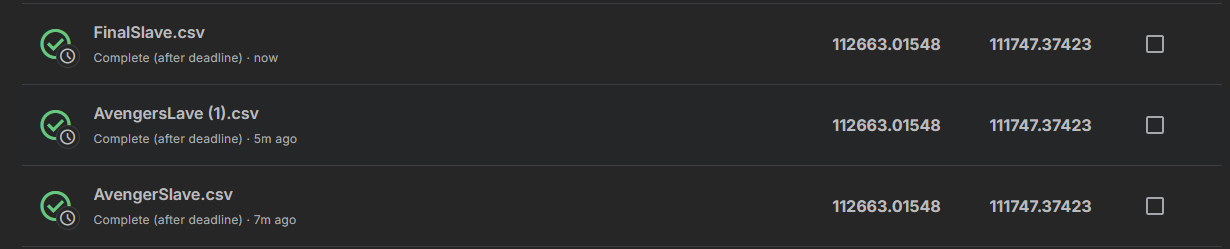

## gg.....아니 뭔가 잘못된거 아닌가.. 심지어 이번 어쎔블은 rsme값이 